# Predicting Song Popularity from Audio Features Across Musical Eras

### A Comparison of Kernel Regression, LASSO, and Decision Tree Models

## Introduction

Streaming platforms and record labels routinely make decisions about which 
songs to promote, yet these decisions are often guided by intuition or by 
whatever genre trends are currently popular rather than by systematic 
analysis of the music itself. This project asks a direct question about 
that gap. Which audio characteristics, such as danceability, energy, 
tempo, and valence, are most predictive of a song's popularity, and has 
the strength of these relationships shifted between older and more 
recently released songs?

Audio features offer a measurable, pre-release signal that does not 
depend on marketing spend or an artist's existing fanbase. If certain 
features are consistently linked to popularity, that information could 
help guide production or promotional decisions before a song is 
released rather than after its performance is already known. If these 
relationships have shifted over time, strategies built on older data 
may no longer apply, and decisions grounded in outdated assumptions 
risk wasting budget or misdirecting effort.

This analysis uses the 30,000 Spotify Songs dataset, which provides 
audio features, release dates, and popularity scores for a wide range 
of tracks. Three modeling approaches are applied to the data: kernel 
regression, to capture smooth nonlinear relationships between features 
and popularity, LASSO regression, to identify which features remain 
predictive after penalization, and decision tree regression, to detect 
threshold effects that a smooth model would miss. Sequential feature 
selection is used alongside these models as an independent check on 
feature importance. Model performance is assessed using root mean 
squared error, which reports prediction error directly in popularity 
points, and R-squared, which indicates how much variance in popularity 
each model explains. Results are compared across older and more recent 
subsets of the data to evaluate whether the relationships between audio 
features and popularity have remained stable over time.

## Data Description

Let's take a look into the data before any cleaning.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# checking columns and shape of dataset
df = pd.read_csv("data/spotify_songs.csv")
df.head()

,track_id,track_name,track_artist,track_popularity,track_album_id,track_album_name,track_album_release_date,playlist_name,playlist_id,playlist_genre,...,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
0,6f807x0ima9a1j3VPbc7VN,I Don't Care (with Justin Bieber) - Loud Luxur...,Ed Sheeran,66,2oCs0DGTsRO98Gh5ZSl2Cx,I Don't Care (with Justin Bieber) [Loud Luxury...,2019-06-14,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,6,-2.634,1,0.0583,0.1020,0.000000,0.0653,0.518,122.036,194754
1,0r7CVbZTWZgbTCYdfa2P31,Memories - Dillon Francis Remix,Maroon 5,67,63rPSO264uRjW1X5E6cWv6,Memories (Dillon Francis Remix),2019-12-13,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,11,-4.969,1,0.0373,0.0724,0.004210,0.3570,0.693,99.972,162600
2,1z1Hg7Vb0AhHDiEmnDE79l,All the Time - Don Diablo Remix,Zara Larsson,70,1HoSmj2eLcsrR0vE9gThr4,All the Time (Don Diablo Remix),2019-07-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,1,-3.432,0,0.0742,0.0794,0.000023,0.1100,0.613,124.008,176616
3,75FpbthrwQmzHlBJLuGdC7,Call You Mine - Keanu Silva Remix,The Chainsmokers,60,1nqYsOef1yKKuGOVchbsk6,Call You Mine - The Remixes,2019-07-19,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,7,-3.778,1,0.1020,0.0287,0.000009,0.2040,0.277,121.956,169093
4,1e8PAfcKUYoKkxPhrHqw4x,Someone You Loved - Future Humans Remix,Lewis Capaldi,69,7m7vv9wlQ4i0LFuJiE2zsQ,Someone You Loved (Future Humans Remix),2019-03-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,1,-4.672,1,0.0359,0.0803,0.000000,0.0833,0.725,123.976,189052


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32833 entries, 0 to 32832
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   track_id                  32833 non-null  str    
 1   track_name                32828 non-null  str    
 2   track_artist              32828 non-null  str    
 3   track_popularity          32833 non-null  int64  
 4   track_album_id            32833 non-null  str    
 5   track_album_name          32828 non-null  str    
 6   track_album_release_date  32833 non-null  str    
 7   playlist_name             32833 non-null  str    
 8   playlist_id               32833 non-null  str    
 9   playlist_genre            32833 non-null  str    
 10  playlist_subgenre         32833 non-null  str    
 11  danceability              32833 non-null  float64
 12  energy                    32833 non-null  float64
 13  key                       32833 non-null  int64  
 14  loudness         

In [3]:
# checking for nulls
print(df.isnull().sum())

track_id                    0
track_name                  5
track_artist                5
track_popularity            0
track_album_id              0
track_album_name            5
track_album_release_date    0
playlist_name               0
playlist_id                 0
playlist_genre              0
playlist_subgenre           0
danceability                0
energy                      0
key                         0
loudness                    0
mode                        0
speechiness                 0
acousticness                0
instrumentalness            0
liveness                    0
valence                     0
tempo                       0
duration_ms                 0
dtype: int64


In [4]:
# checking for duplicate rows
print(df.duplicated().sum())

0


In [5]:
df.describe()

,track_popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
count,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000
mean,42.477081,0.654850,0.698619,5.374471,-6.719499,0.565711,0.107068,0.175334,0.084747,0.190176,0.510561,120.881132,225799.811622
std,24.984074,0.145085,0.180910,3.611657,2.988436,0.495671,0.101314,0.219633,0.224230,0.154317,0.233146,26.903624,59834.006182
min,0.000000,0.000000,0.000175,0.000000,-46.448000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4000.000000
25%,24.000000,0.563000,0.581000,2.000000,-8.171000,0.000000,0.041000,0.015100,0.000000,0.092700,0.331000,99.960000,187819.000000
50%,45.000000,0.672000,0.721000,6.000000,-6.166000,1.000000,0.062500,0.080400,0.000016,0.127000,0.512000,121.984000,216000.000000
75%,62.000000,0.761000,0.840000,9.000000,-4.645000,1.000000,0.132000,0.255000,0.004830,0.248000,0.693000,133.918000,253585.000000
max,100.000000,0.983000,1.000000,11.000000,1.275000,1.000000,0.918000,0.994000,0.994000,0.996000,0.991000,239.440000,517810.000000


In [6]:
# checking release dates for later era split
print(df['track_album_release_date'].min())
print(df['track_album_release_date'].max())

1957-01-01
2020-01-29


The dataset used for this analysis is the 30,000 Spotify Songs dataset 
from Kaggle, containing 32,833 records and 23 columns. Each row represents 
a single track and includes audio features, track and album metadata, 
genre, release date, and a popularity score.

The audio features relevant to this analysis are danceability, energy, 
valence, tempo, loudness, and acousticness, each scored on a scale 
specific to the feature. Danceability, energy, valence, and acousticness 
are measured on a scale from 0 to 1, with valence reflecting the 
musical positivity conveyed by a track and acousticness reflecting the 
likelihood that a track is acoustic rather than electronically produced. 
Tempo is measured in beats per minute, and loudness is measured in 
decibels, typically ranging from around -60 to 0, with values closer to 
0 indicating a louder track.

Track popularity is scored from 0 to 100, with an average score of 
42.48 across the dataset. This places the typical track closer to the 
lower half of the scale, suggesting that high popularity scores are 
concentrated among a smaller set of tracks rather than spread evenly 
across the full range.

Release dates range from 01/01/1957 to 01/29/2020, which 
provides the basis for the era comparison central to the second research 
question. The dataset contains 15 missing values across 3 columns 
and 0 duplicate rows, both of which are addressed in the data cleaning 
section that follows.

## Data Cleaning

Let's start with addressing the missing values in our dataset. We have already determined that we had 15 missing values across 3 columns. Let's see which observations these are.

In [7]:
df[df['track_artist'].isna()==True]

,track_id,track_name,track_artist,track_popularity,track_album_id,track_album_name,track_album_release_date,playlist_name,playlist_id,playlist_genre,...,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
8151,69gRFGOWY9OMpFJgFol1u0,NaN,NaN,0,717UG2du6utFe7CdmpuUe3,NaN,2012-01-05,HIP&HOP,5DyJsJZOpMJh34WvUrQzMV,rap,...,6,-7.635,1,0.1760,0.0410,0.00000,0.1160,0.649,95.999,282707
9282,5cjecvX0CmC9gK0Laf5EMQ,NaN,NaN,0,3luHJEPw434tvNbme3SP8M,NaN,2017-12-01,GANGSTA Rap,5GA8GDo7RQC3JEanT81B3g,rap,...,11,-5.364,0,0.3190,0.0534,0.00000,0.5530,0.191,146.153,202235
9283,5TTzhRSWQS4Yu8xTgAuq6D,NaN,NaN,0,3luHJEPw434tvNbme3SP8M,NaN,2017-12-01,GANGSTA Rap,5GA8GDo7RQC3JEanT81B3g,rap,...,10,-5.907,0,0.3070,0.0963,0.00000,0.0888,0.505,86.839,206465
19568,3VKFip3OdAvv4OfNTgFWeQ,NaN,NaN,0,717UG2du6utFe7CdmpuUe3,NaN,2012-01-05,Reggaeton viejito🔥,0si5tw70PIgPkY1Eva6V8f,latin,...,11,-6.075,0,0.0366,0.0606,0.00653,0.1030,0.726,97.017,252773
19811,69gRFGOWY9OMpFJgFol1u0,NaN,NaN,0,717UG2du6utFe7CdmpuUe3,NaN,2012-01-05,latin hip hop,3nH8aytdqNeRbcRCg3dw9q,latin,...,6,-7.635,1,0.1760,0.0410,0.00000,0.1160,0.649,95.999,282707


Notice that tracks that have a null track name also have a track popularity of 0. These look like broken entries rather than missing values. Could be due to Spotify's inability to load the metadata. Now that we have identified the null values, let's remove them from the dataset.

In [8]:
cleaned_df = df.dropna()
cleaned_df.isna().any().sum() # should return 0!

np.int64(0)

In [9]:
# checking the new dataframe shape
print(cleaned_df.shape)

(32828, 23)


Since an era split is part of the analysis, `track_album_release_date` 
needs to be converted to a usable format. The era comparison only 
requires a release year rather than a full date, and every entry in 
`track_album_release_date` begins with a 4-digit year regardless of 
whether the rest of the string is a complete date or just the year 
alone. Extracting the first 4 characters directly avoids the parsing 
issues that came up with the full datetime conversion.

In [10]:
cleaned_df['release_year'] = cleaned_df['track_album_release_date'].str[:4].astype(int)
cleaned_df['release_year'].min(), cleaned_df['release_year'].max()

(np.int64(1957), np.int64(2020))

The dataset spans release years from 1957 to 2020. This range forms the 
basis for the era split used in the second research question.

Text(0.5, 1.0, 'Distribution of Track Release Years')

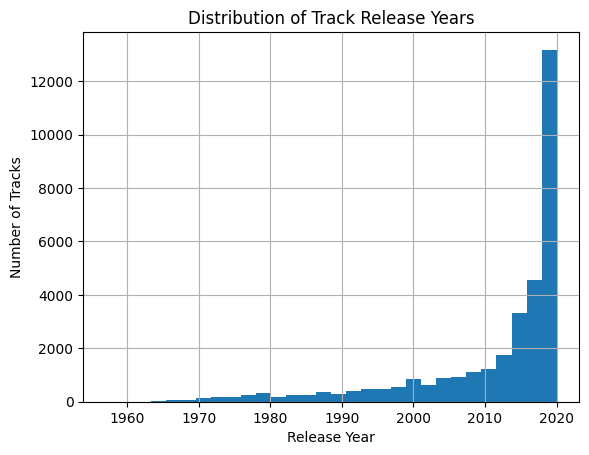

In [11]:
# looking at the distribution of track release years
cleaned_df['release_year'].hist(bins=30)
plt.xlabel('Release Year')
plt.ylabel('Number of Tracks')
plt.title('Distribution of Track Release Years')

With release dates simplified to just the year, the next step is 
dividing the songs into two time periods for comparison. Simply 
splitting the dataset in half by count is not the right approach here, 
since we can see from the chart that the number of songs released each year grows quickly toward the 
end of the dataset, meaning an even split by row count would lump 
together six decades of older music against only a couple of recent 
years. Instead, the songs are divided into an older group and a recent 
group based on a chosen cutoff year, with 2015 marking the start of the 
recent period. This split gives a clearer 
picture of how music from a well established earlier period compares to 
music from recent years.

In [12]:
cleaned_df['release_year'].value_counts().sort_index()

release_year
1957       2
1958       1
1960       4
1961       1
1962       2
        ... 
2016    2127
2017    2428
2018    3312
2019    9081
2020     785
Name: count, Length: 63, dtype: int64

The 2020 count drops sharply below prior years, which does not reflect 
fewer releases but rather that the dataset only captures part of that 
year. Tracks from 2020 are excluded from the era comparison for this 
reason. The remaining years are split into an older group and a recent 
group using 2015 as the cutoff, giving the recent group five full years 
of consistently high track volume while the older group covers 
everything before the dataset's growth phase.

In [ ]:
# creating the era split
cleaned_df = cleaned_df[cleaned_df['release_year'] != 2020]
cleaned_df['era'] = cleaned_df['release_year'].apply(lambda x: 'older' if x < 2015 else 'recent')
cleaned_df['era'].value_counts()

era
recent    18727
older     13316
Name: count, dtype: int64

This split produces 13,316 tracks in the older group and 18,727 tracks 
in the recent group (roughly 42% and 58% respectively), which will be 
used as the two comparison groups for the second research question.

Before moving into scaling and modeling, the six features used in this 
analysis, danceability, energy, valence, tempo, loudness, and 
acousticness, are checked for values that fall outside a plausible 
range. A tempo of 0 beats per minute is checked specifically, since a 
released track having no detectable tempo at all is implausible and 
more likely reflects a failure in Spotify's audio analysis than an 
actual musical property of the track.

In [14]:
features = ['danceability', 'energy', 'valence', 'tempo', 'loudness', 'acousticness']
cleaned_df[features].describe()

,danceability,energy,valence,tempo,loudness,acousticness
count,32043.000000,32043.000000,32043.000000,32043.000000,32043.000000,32043.000000
mean,0.654431,0.699295,0.511573,120.841048,-6.718559,0.174540
std,0.145081,0.180836,0.233148,26.896418,2.991334,0.219288
min,0.000000,0.000175,0.000000,0.000000,-46.448000,0.000000
25%,0.562000,0.582000,0.332000,99.955000,-8.173000,0.014900
50%,0.671000,0.722000,0.514000,121.982000,-6.163000,0.079400
75%,0.760000,0.841000,0.695000,133.811500,-4.643000,0.253000
max,0.983000,1.000000,0.991000,239.440000,1.275000,0.994000


In [15]:
# checking specifically for tempo values of 0
print((cleaned_df['tempo'] == 0).sum())
cleaned_df[cleaned_df['tempo'] == 0][features]

1


,danceability,energy,valence,tempo,loudness,acousticness
11363,0.0,0.315,0.0,0.0,-26.087,0.0


1 track has a tempo of 0, which is not a valid tempo for a released 
track and most likely reflects a failure in Spotify's tempo detection 
rather than an actual value. This row is dropped from the dataset, 
since keeping it would put an implausible outlier directly into the 
feature this analysis is built around.

In [16]:
cleaned_df = cleaned_df[cleaned_df['tempo'] != 0]
print(cleaned_df.shape)

(32042, 25)


With the tempo issue resolved, the next feature to check is duration. 
`duration_ms` is checked for tracks that are unusually short or long 
compared to a typical song length, since interludes, intros, or 
long-form ambient tracks can behave differently from standard songs and 
may distort the relationships this analysis is measuring.

count     32042.000000
mean     226531.656794
std       59996.862102
min       29493.000000
25%      188417.250000
50%      216868.000000
75%      254467.000000
max      517810.000000
Name: duration_ms, dtype: float64


Text(0.5, 1.0, 'Distribution of Track Duration')

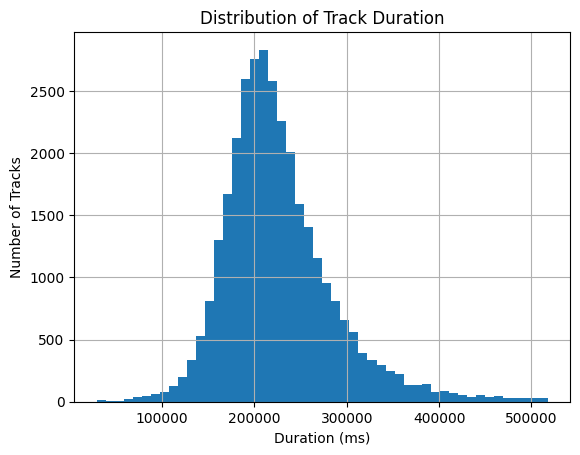

In [17]:
print(cleaned_df['duration_ms'].describe())
cleaned_df['duration_ms'].hist(bins=50)
plt.xlabel('Duration (ms)')
plt.ylabel('Number of Tracks')
plt.title('Distribution of Track Duration')

The distribution of track duration follows a roughly normal shape 
centered around 3.5 minutes, which matches typical commercial song 
length and shows no sign of a systemic problem the way the tempo values 
did. Even so, a small number of tracks at either extreme are worth 
checking individually. A track lasting only a few seconds is unlikely 
to be a full song, and an unusually long track could represent 
something atypical, such as an extended mix or ambient piece, that may 
behave differently from a standard song in the analysis. Filtering out 
these extreme cases keeps the dataset focused on tracks that reasonably 
represent a typical listening experience.

In [20]:
# using the IQR method to define bounds for track duration
Q1 = cleaned_df['duration_ms'].quantile(0.25)
Q3 = cleaned_df['duration_ms'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
print(lower_bound, upper_bound)

# filtering out tracks that fall outside the typical duration range
cleaned_df = cleaned_df[(cleaned_df['duration_ms'] >= lower_bound) & (cleaned_df['duration_ms'] <= upper_bound)]
print(cleaned_df.shape)

97276.5 337676.5
(30250, 25)


Applying the IQR method sets a lower bound of roughly 97,000 
milliseconds and an upper bound of roughly 338,000 milliseconds, 
equivalent to about 1.6 minutes and 5.6 minutes. Tracks outside this 
range are removed, bringing the dataset down to 30,250 rows.

With duration handled, the last item from the anomaly check is loudness. 
An earlier look at the dataset's summary statistics showed a maximum 
loudness value of 1.275, which sits just above 0 dB. Since loudness is 
typically negative, with 0 representing the loudest a track can be 
mixed before clipping, a small number of tracks above that line are 
worth a closer look before deciding whether they represent valid, 
heavily mastered tracks or a data issue similar to the tempo case.

In [21]:
# checking how many tracks have a loudness above 0 dB
print((cleaned_df['loudness'] > 0).sum())
cleaned_df[cleaned_df['loudness'] > 0][['track_name', 'loudness']]

6


,track_name,loudness
9883,Nails,0.551
10438,Crema,0.326
10458,Rockstar,0.642
12197,Raw Power - Iggy Pop Mix,1.275
27716,Escape From Love - Curbi Remix,1.135
30339,Vidrado Em Você,0.302


6 tracks show a loudness value slightly above 0 dB, the highest being 
1.275. Given the small number of tracks affected and the modest size of 
the overshoot, these are treated as valid, heavily mastered tracks 
rather than a data issue, and are kept in the dataset without 
modification.

## Data Preparation